# 02. Biến mục tiêu: doanh thu tuần × danh mục

**Mục tiêu:** Dựng biến mục tiêu của đồ án (doanh thu tuần × 4 danh mục) từ dữ liệu giao dịch, đối soát với `sales.csv`, so sánh các định nghĩa doanh thu.

**Bảng dữ liệu dùng:** `order_items`, `orders`, `products`, `sales`

In [1]:
import sys
from pathlib import Path

# Tìm thư mục gốc repo (chứa src/ds317) để import thư viện chung
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "ds317").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ds317 import load, load_many, order_lines, revenue_daily, weekly_category, REVENUE_LABELS
from ds317.viz import setup_style, nb_out, save_fig, source_note, key_numbers, MILLION, UNIT, NOTE_SALES, NOTE_TRAFFIC

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)
setup_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
FIG, TAB = nb_out("02_bien_muc_tieu_tuan_danh_muc")
print("Ảnh lưu tại:", FIG.relative_to(ROOT))

Ảnh lưu tại: outputs\eda\02_bien_muc_tieu_tuan_danh_muc


**Ba định nghĩa doanh thu** (`ds317.REVENUE_KINDS`):

| kind | Công thức | Đơn huỷ |
|---|---|---|
| `gross_all` | SUM(`quantity × unit_price`) | gồm |
| `gross_excl_cancelled` | SUM(`quantity × unit_price`) | bỏ |
| `net_excl_cancelled` | SUM(`quantity × unit_price − discount_amount`) | bỏ |

**Quy ước tuần:** Thứ Hai → Chủ nhật (pandas `W-SUN`), `week_start` = ngày Thứ Hai. Tuần đầu (từ 2012-07-04) và tuần cuối
(đến 2022-12-31) không đủ 7 ngày → cột `is_partial_week = True`.

Notebook này **không chọn** định nghĩa chính thức: in cả `gross_all` và `net_excl_cancelled` để nhóm quyết ở Giai đoạn 3.

In [2]:
lines = order_lines()
sales = load("sales").set_index("Date")
KINDS = list(REVENUE_LABELS)
print(f"order_lines: {len(lines):,} dòng | đơn huỷ chiếm {lines.is_cancelled.mean() * 100:.2f}% số dòng")

order_lines: 714,669 dòng | đơn huỷ chiếm 9.19% số dòng


## Doanh thu dựng từ order_items có khớp sales.Revenue không? Mỗi định nghĩa lệch bao nhiêu?

,dinh_nghia,lech_tuyet_doi_max_trieu,lech_tuyet_doi_tb_trieu,lech_pct_tb,lech_pct_max,tong_ky_ty_le_so_voi_sales_pct
gross_all,"Doanh thu gộp, gồm đơn huỷ, trước chiết khấu (...",0.0000,0.0000,0.0000,0.0000,100.0000
gross_excl_cancelled,"Doanh thu gộp, bỏ đơn huỷ, trước chiết khấu",1.8904,0.3955,9.2064,30.8553,90.7739
net_excl_cancelled,"Doanh thu net, bỏ đơn huỷ, sau chiết khấu",3.7388,0.5731,13.9033,39.9271,86.6308


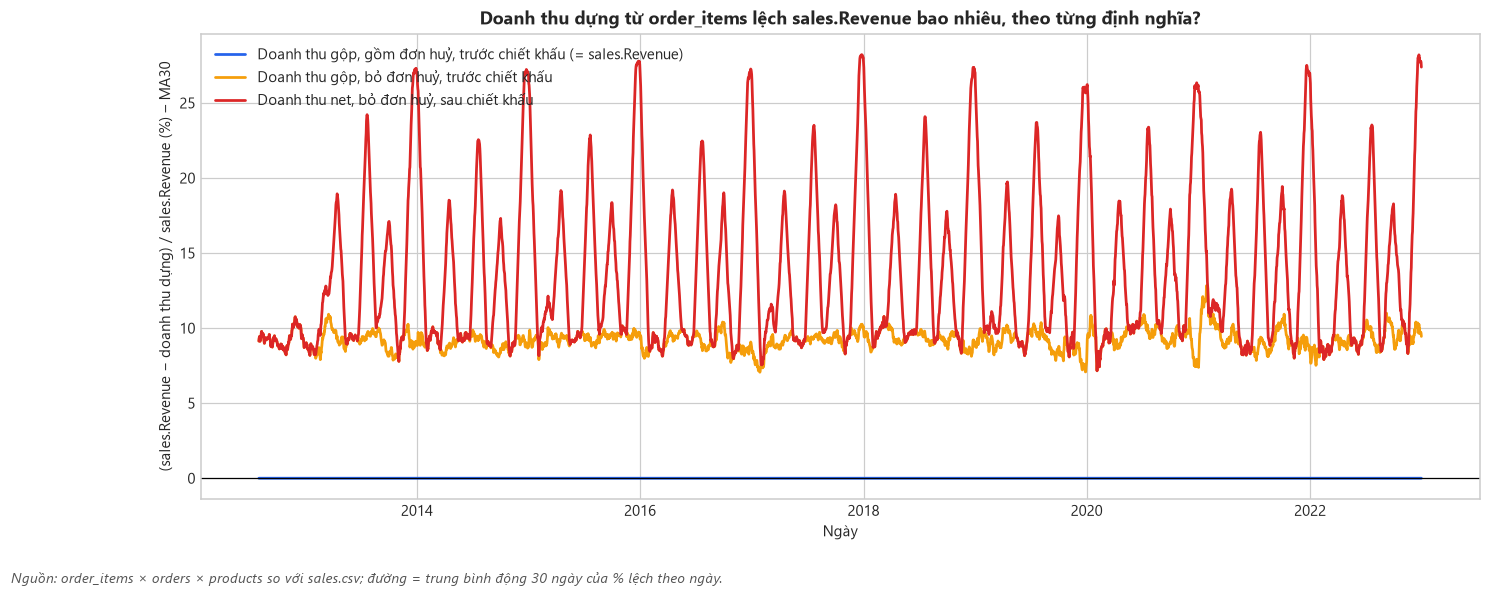

  đã lưu 02a_doi_soat_sales.png


In [3]:
daily = pd.concat({k: revenue_daily(lines, k) for k in KINDS}, axis=1).reindex(sales.index)
gap_pct = daily.rsub(sales["Revenue"], axis=0).div(sales["Revenue"], axis=0) * 100   # (sales − dựng) / sales
recon = pd.DataFrame({
    "dinh_nghia": [REVENUE_LABELS[k] for k in KINDS],
    "lech_tuyet_doi_max_trieu": [(sales.Revenue - daily[k]).abs().max() / MILLION for k in KINDS],
    "lech_tuyet_doi_tb_trieu": [(sales.Revenue - daily[k]).abs().mean() / MILLION for k in KINDS],
    "lech_pct_tb": [gap_pct[k].mean() for k in KINDS],
    "lech_pct_max": [gap_pct[k].max() for k in KINDS],
    "tong_ky_ty_le_so_voi_sales_pct": [daily[k].sum() / sales.Revenue.sum() * 100 for k in KINDS],
}, index=KINDS)
recon.to_csv(TAB / "doi_soat_sales.csv", encoding="utf-8-sig")
display(recon.round(4))

cogs_gap = (sales.COGS - lines.groupby("order_date").cogs_line.sum().reindex(sales.index)).abs().max()
fig, ax = plt.subplots(figsize=(15, 5.5))
for k, c in zip(KINDS, ["#2563eb", "#f59e0b", "#dc2626"]):
    ax.plot(gap_pct.index, gap_pct[k].rolling(30).mean(), color=c, lw=1.8, label=REVENUE_LABELS[k])
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Doanh thu dựng từ order_items lệch sales.Revenue bao nhiêu, theo từng định nghĩa?", fontweight="bold")
ax.set_ylabel("(sales.Revenue − doanh thu dựng) / sales.Revenue (%) – MA30")
ax.set_xlabel("Ngày")
ax.legend(loc="upper left")
source_note(fig, "Nguồn: order_items × orders × products so với sales.csv; đường = trung bình động 30 ngày của % lệch theo ngày.")
save_fig(fig, FIG / "02a_doi_soat_sales.png")

In [4]:
key_numbers({
    "gross_all: |lệch| lớn nhất": f"{recon.loc['gross_all', 'lech_tuyet_doi_max_trieu']:.6f} {UNIT} (khớp từng ngày)",
    "gross_excl_cancelled thấp hơn sales trung bình": f"{recon.loc['gross_excl_cancelled', 'lech_pct_tb']:.2f}%/ngày (tối đa {recon.loc['gross_excl_cancelled', 'lech_pct_max']:.1f}%)",
    "net_excl_cancelled thấp hơn sales trung bình": f"{recon.loc['net_excl_cancelled', 'lech_pct_tb']:.2f}%/ngày (tối đa {recon.loc['net_excl_cancelled', 'lech_pct_max']:.1f}%)",
    "sales.COGS vs SUM(quantity × cogs): |lệch| lớn nhất": f"{cogs_gap:.6f} đồng",
})

Số liệu chính:
  - gross_all: |lệch| lớn nhất: 0.000000 Triệu VNĐ (khớp từng ngày)
  - gross_excl_cancelled thấp hơn sales trung bình: 9.21%/ngày (tối đa 30.9%)
  - net_excl_cancelled thấp hơn sales trung bình: 13.90%/ngày (tối đa 39.9%)
  - sales.COGS vs SUM(quantity × cogs): |lệch| lớn nhất: 0.004999 đồng


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Doanh thu tuần của 4 danh mục biến động thế nào (gộp vs net)?

,week_start,category,revenue,cogs,units,n_orders,n_days,is_partial_week
0,2012-07-02,Casual,266385.96,2.048865e+05,47,10,5,True
1,2012-07-02,GenZ,173844.34,1.441247e+05,121,26,5,True
2,2012-07-02,Outdoor,975925.82,7.900948e+05,491,91,5,True
3,2012-07-02,Streetwear,14541977.53,1.142897e+07,1745,387,5,True
4,2012-07-09,Casual,437785.54,3.689670e+05,120,27,7,False


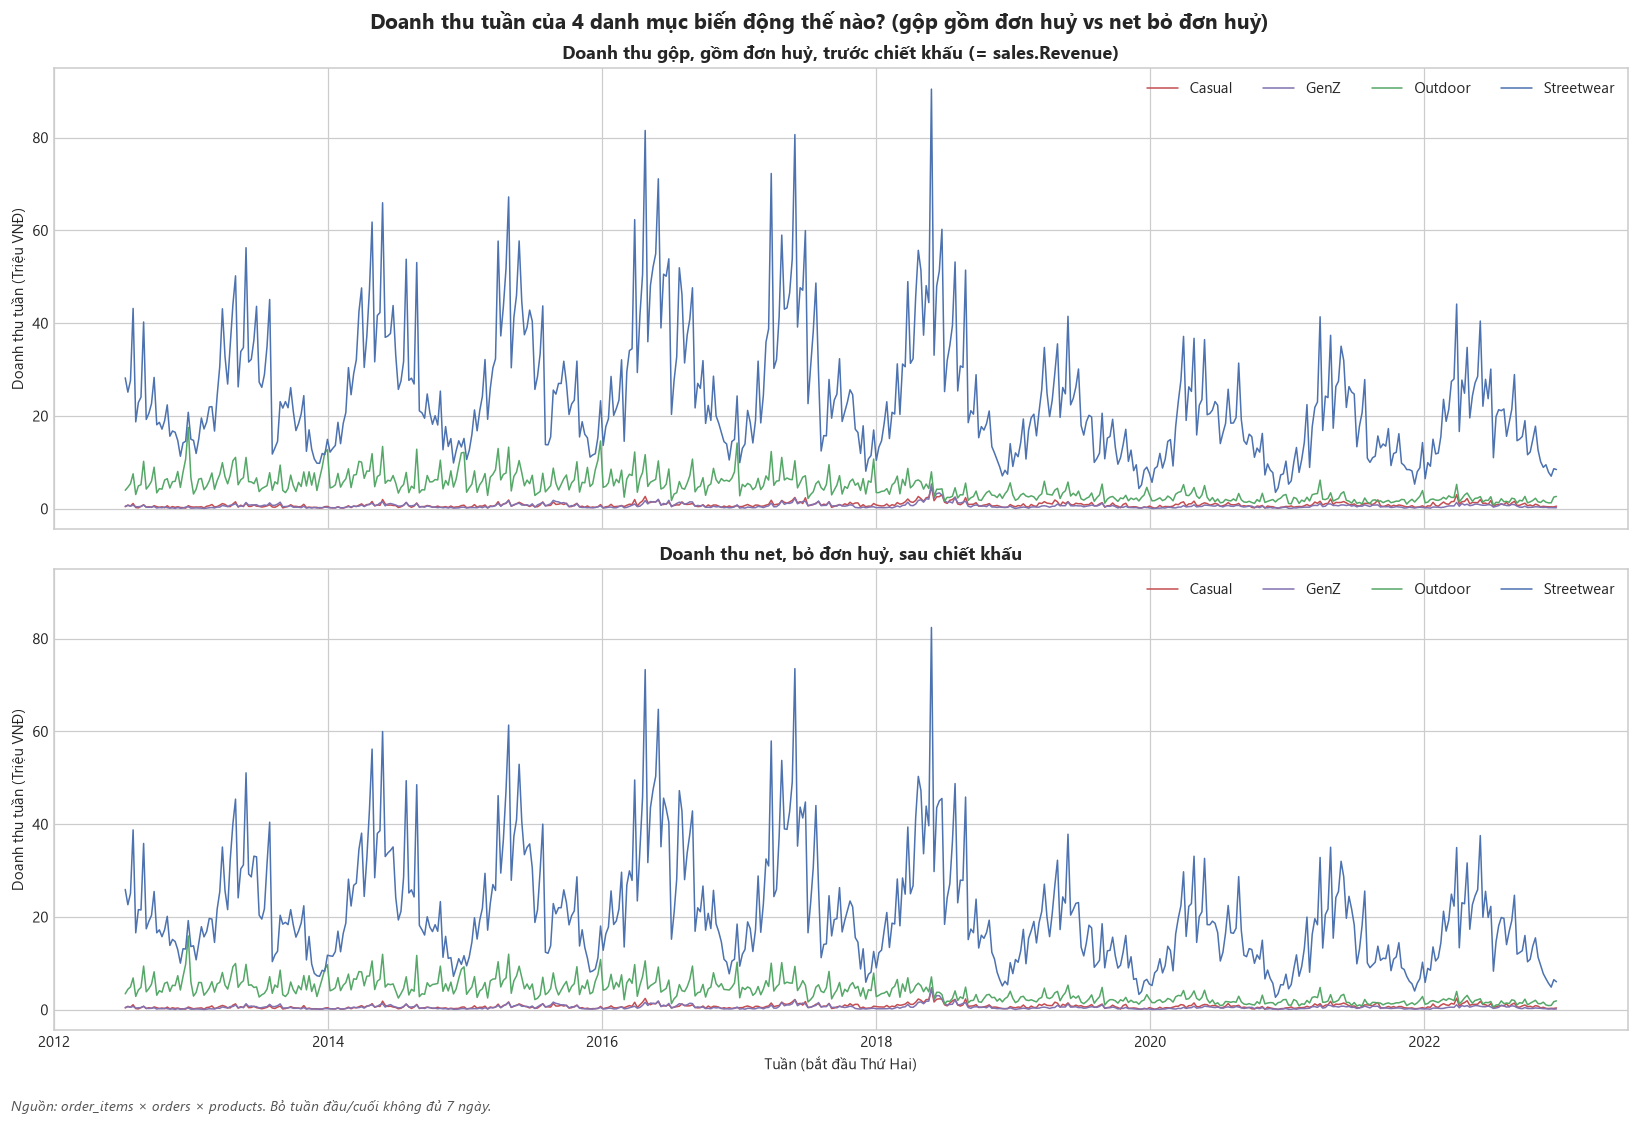

  đã lưu 02b_doanh_thu_tuan_danh_muc.png


In [5]:
W = {k: weekly_category(lines, k) for k in ["gross_all", "net_excl_cancelled"]}
for k, w in W.items():
    w.to_csv(TAB / f"weekly_category_{k}.csv", index=False, encoding="utf-8-sig")
display(W["gross_all"].head())

COLORS = {"Casual": "#C44E52", "GenZ": "#8172B2", "Outdoor": "#55A868", "Streetwear": "#4C72B0"}
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True, sharey=True)
for ax, (k, w) in zip(axes, W.items()):
    full = w[~w.is_partial_week]
    for cat, g in full.groupby("category"):
        ax.plot(g.week_start, g.revenue / MILLION, color=COLORS[cat], lw=1, label=cat)
    ax.set_title(REVENUE_LABELS[k], fontweight="bold")
    ax.set_ylabel(f"Doanh thu tuần ({UNIT})")
    ax.legend(loc="upper right", ncol=4)
axes[1].set_xlabel("Tuần (bắt đầu Thứ Hai)")
fig.suptitle("Doanh thu tuần của 4 danh mục biến động thế nào? (gộp gồm đơn huỷ vs net bỏ đơn huỷ)", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, "Nguồn: order_items × orders × products. Bỏ tuần đầu/cuối không đủ 7 ngày.")
save_fig(fig, FIG / "02b_doanh_thu_tuan_danh_muc.png")

In [6]:
g, n = (W[k][~W[k].is_partial_week] for k in W)
stats = pd.DataFrame({
    "tb_tuan_gross_trieu": g.groupby("category").revenue.mean() / MILLION,
    "tb_tuan_net_trieu": n.groupby("category").revenue.mean() / MILLION,
    "net_tren_gross_pct": n.groupby("category").revenue.sum() / g.groupby("category").revenue.sum() * 100,
    "he_so_bien_thien_gross": g.groupby("category").revenue.std() / g.groupby("category").revenue.mean(),
    "tuan_cao_nhat_gross": g.loc[g.groupby("category").revenue.idxmax()].set_index("category").week_start.dt.date,
})
stats.to_csv(TAB / "thong_ke_tuan_theo_danh_muc.csv", encoding="utf-8-sig")
display(stats.round(3))
key_numbers({
    "Số tuần đủ 7 ngày": f"{g.week_start.nunique()} tuần × {g.category.nunique()} danh mục = {len(g):,} mẫu",
    "Danh mục doanh thu tuần TB cao nhất / thấp nhất (gộp)": f"{stats.tb_tuan_gross_trieu.idxmax()} ({stats.tb_tuan_gross_trieu.max():.1f}) / {stats.tb_tuan_gross_trieu.idxmin()} ({stats.tb_tuan_gross_trieu.min():.1f}) {UNIT}",
    "Net / gộp theo danh mục": ", ".join(f"{c} {v:.1f}%" for c, v in stats.net_tren_gross_pct.items()),
    "Hệ số biến thiên (std/mean) cao nhất": f"{stats.he_so_bien_thien_gross.idxmax()} ({stats.he_so_bien_thien_gross.max():.2f})",
})

,tb_tuan_gross_trieu,tb_tuan_net_trieu,net_tren_gross_pct,he_so_bien_thien_gross,tuan_cao_nhat_gross
category,,,,,
Casual,0.841,0.730,86.716,0.619,2018-05-28
GenZ,0.628,0.547,87.100,0.793,2018-05-28
Outdoor,4.562,3.900,85.498,0.595,2012-12-24
Streetwear,24.002,20.844,86.841,0.563,2018-05-28


Số liệu chính:


  - Số tuần đủ 7 ngày: 546 tuần × 4 danh mục = 2,184 mẫu
  - Danh mục doanh thu tuần TB cao nhất / thấp nhất (gộp): Streetwear (24.0) / GenZ (0.6) Triệu VNĐ
  - Net / gộp theo danh mục: Casual 86.7%, GenZ 87.1%, Outdoor 85.5%, Streetwear 86.8%
  - Hệ số biến thiên (std/mean) cao nhất: GenZ (0.79)


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Tỷ trọng doanh thu của từng danh mục thay đổi thế nào qua các năm?

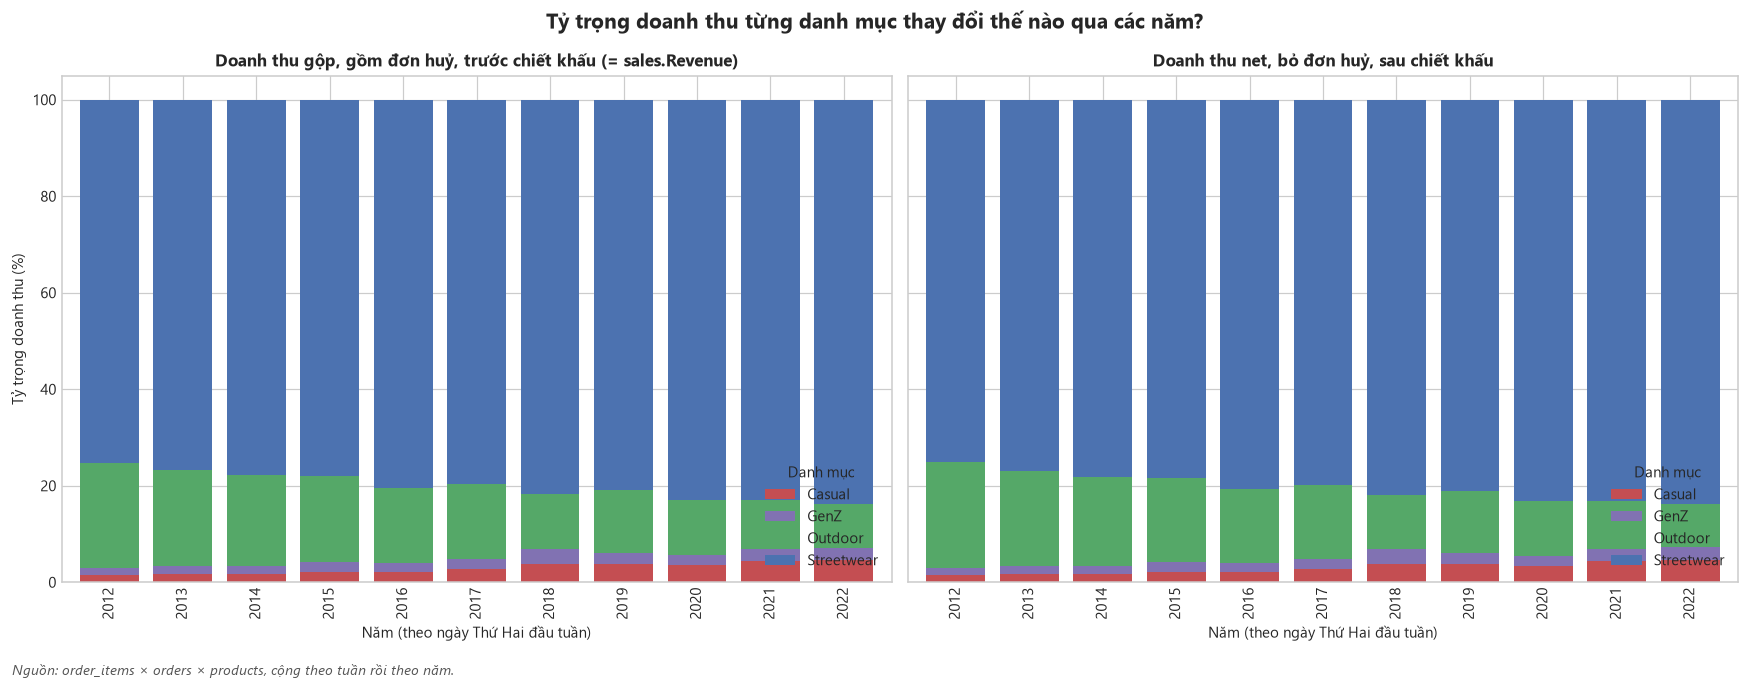

  đã lưu 02c_ty_trong_danh_muc_theo_nam.png


category,Casual,GenZ,Outdoor,Streetwear
Year,,,,
2012,1.59,1.27,21.94,75.20
2013,1.75,1.63,19.96,76.66
2014,1.71,1.57,18.90,77.82
2015,2.08,2.01,17.92,77.99
2016,2.18,1.87,15.40,80.54
2017,2.74,2.03,15.50,79.74
2018,3.82,3.12,11.27,81.78
2019,3.84,2.27,13.01,80.89
2020,3.48,2.09,11.46,82.97


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
shares = {}
for ax, (k, w) in zip(axes, W.items()):
    s = w.assign(Year=w.week_start.dt.year).pivot_table(index="Year", columns="category", values="revenue", aggfunc="sum")
    s = s.div(s.sum(axis=1), axis=0) * 100
    shares[k] = s
    s.plot(kind="bar", stacked=True, ax=ax, color=[COLORS[c] for c in s.columns], width=0.8)
    ax.set_title(REVENUE_LABELS[k], fontweight="bold", fontsize=11)
    ax.set_xlabel("Năm (theo ngày Thứ Hai đầu tuần)")
    ax.set_ylabel("Tỷ trọng doanh thu (%)")
    ax.legend(title="Danh mục", loc="lower right")
fig.suptitle("Tỷ trọng doanh thu từng danh mục thay đổi thế nào qua các năm?", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, "Nguồn: order_items × orders × products, cộng theo tuần rồi theo năm.")
save_fig(fig, FIG / "02c_ty_trong_danh_muc_theo_nam.png")
pd.concat(shares, axis=1).round(2).to_csv(TAB / "ty_trong_danh_muc_theo_nam.csv", encoding="utf-8-sig")
shares["gross_all"].round(2)

In [8]:
s = shares["gross_all"]
key_numbers({
    "Streetwear: tỷ trọng thấp nhất / cao nhất (gộp)": f"{s.Streetwear.min():.1f}% ({s.Streetwear.idxmin()}) / {s.Streetwear.max():.1f}% ({s.Streetwear.idxmax()})",
    "Casual + GenZ cộng lại (gộp, toàn kỳ)": f"{(W['gross_all'].query('category in [\"Casual\", \"GenZ\"]').revenue.sum() / W['gross_all'].revenue.sum() * 100):.2f}%",
    "Chênh tỷ trọng gộp vs net lớn nhất": f"{(shares['gross_all'] - shares['net_excl_cancelled']).abs().max().max():.2f} điểm %",
})

Số liệu chính:
  - Streetwear: tỷ trọng thấp nhất / cao nhất (gộp): 75.2% (2012) / 83.8% (2022)
  - Casual + GenZ cộng lại (gộp, toàn kỳ): 4.89%
  - Chênh tỷ trọng gộp vs net lớn nhất: 0.36 điểm %


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Có tuần × danh mục nào không bán được gì không? Tuần thấp nhất thấp cỡ nào?

In [9]:
rows = []
for k, w in W.items():
    for cat, gcat in w.groupby("category"):
        full = gcat[~gcat.is_partial_week]
        rows.append({"dinh_nghia": k, "category": cat, "so_tuan": len(gcat), "so_tuan_bang_0": int((gcat.revenue == 0).sum()),
                     "tuan_thap_nhat": full.loc[full.revenue.idxmin(), "week_start"].date(),
                     "doanh_thu_thap_nhat_trieu": full.revenue.min() / MILLION,
                     "so_don_thap_nhat": int(full.n_orders.min())})
zero = pd.DataFrame(rows)
zero.to_csv(TAB / "tuan_khong_ban.csv", index=False, encoding="utf-8-sig")
if zero.so_tuan_bang_0.sum() > 20:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=zero, x="category", y="so_tuan_bang_0", hue="dinh_nghia", ax=ax)
    ax.set_title("Mỗi danh mục có bao nhiêu tuần không bán được gì?", fontweight="bold")
    ax.set_ylabel("Số tuần doanh thu = 0")
    save_fig(fig, FIG / "02d_tuan_khong_ban.png")
else:
    print("Số tuần × danh mục bằng 0 ít (≤ 20) → hiển thị dạng bảng, không vẽ chart 02d.")
zero.round(3)

Số tuần × danh mục bằng 0 ít (≤ 20) → hiển thị dạng bảng, không vẽ chart 02d.


,dinh_nghia,category,so_tuan,so_tuan_bang_0,tuan_thap_nhat,doanh_thu_thap_nhat_trieu,so_don_thap_nhat
0,gross_all,Casual,548,0,2020-12-07,0.078,7
1,gross_all,GenZ,548,0,2019-01-07,0.057,9
2,gross_all,Outdoor,548,0,2022-07-04,0.752,55
3,gross_all,Streetwear,548,0,2020-11-30,3.539,110
4,net_excl_cancelled,Casual,548,0,2020-12-07,0.051,5
5,net_excl_cancelled,GenZ,548,0,2019-01-07,0.057,9
6,net_excl_cancelled,Outdoor,548,0,2022-07-04,0.573,50
7,net_excl_cancelled,Streetwear,548,0,2020-11-30,2.681,93


In [10]:
key_numbers({
    "Tổng số tuần × danh mục bằng 0 (gộp / net)": f"{zero.query('dinh_nghia == \"gross_all\"').so_tuan_bang_0.sum()} / {zero.query('dinh_nghia == \"net_excl_cancelled\"').so_tuan_bang_0.sum()}",
    "Tuần đủ ngày có doanh thu gộp thấp nhất": ", ".join(f"{r.category} {r.doanh_thu_thap_nhat_trieu:.2f} {UNIT} ({r.tuan_thap_nhat})" for r in zero.query('dinh_nghia == "gross_all"').itertuples()),
    "Số đơn ít nhất trong 1 tuần đủ ngày": ", ".join(f"{r.category} {r.so_don_thap_nhat}" for r in zero.query('dinh_nghia == "gross_all"').itertuples()),
})

Số liệu chính:
  - Tổng số tuần × danh mục bằng 0 (gộp / net): 0 / 0
  - Tuần đủ ngày có doanh thu gộp thấp nhất: Casual 0.08 Triệu VNĐ (2020-12-07), GenZ 0.06 Triệu VNĐ (2019-01-07), Outdoor 0.75 Triệu VNĐ (2022-07-04), Streetwear 3.54 Triệu VNĐ (2020-11-30)
  - Số đơn ít nhất trong 1 tuần đủ ngày: Casual 7, GenZ 9, Outdoor 55, Streetwear 110


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Vấn đề cần nhóm quyết (Giai đoạn 3)

- Biến mục tiêu chính thức dùng định nghĩa nào: `gross_all` (khớp `sales.Revenue`, gồm đơn huỷ, trước chiết khấu) hay `net_excl_cancelled` (doanh thu thực thu)?
- Tuần đầu/cuối không đủ 7 ngày: bỏ hay chuẩn hoá theo số ngày (`n_days`)?
- File để dùng tiếp: `outputs/eda/02_bien_muc_tieu_tuan_danh_muc/tables/weekly_category_<kind>.csv`.